In [1]:
import pandas as pd
import trxtools.methods as ttm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Binding profiles at different gene classes

Use the tt.metaprofiles module to create metaprofiles of sets of genes

In [2]:
import trxtools.profiles.metaprofiles as meta

### Load data

Transform GTF to BED

Keep the gene_type and gene_name columns for filtering

Uncomment the following cell if running for the 1st time, keeping the GTF open takes up a lot of memory so we can use the file saved to disk afterwards.

In [ ]:
# gtf = pd.read_csv("../references/hg41_annotation_gencode_tRNA_rRNA.gtf.gz", sep="\t", header=None,compression="gzip")
# gtf = gtf[gtf[2].isin(['gene'])]
# gtf = pd.concat([
#     gtf.rename(columns={0: 'chr', 1: 'source', 2:'feature_type'}),
#     gtf[8].str.split("; ", expand=True)[[0,1,2]]
#     ], axis=1).rename(columns={0: 'gene_id', 1: 'gene_type', 2:'gene_name'})
# gtf = gtf.drop(columns=[8])
# gtf['gene_id'] = gtf['gene_id'].str.replace('gene_id "', '', regex=False)
# gtf['gene_id'] = gtf['gene_id'].str.replace('"', '', regex=False)
# gtf['gene_type'] = gtf['gene_type'].str.replace('gene_type "', '', regex=False)
# gtf['gene_type'] = gtf['gene_type'].str.replace('"', '', regex=False)
# gtf['gene_name'] = gtf['gene_name'].str.replace('gene_name "', '', regex=False)
# gtf['gene_name'] = gtf['gene_name'].str.replace('"', '', regex=False)
# bed = gtf[['chr', 3, 4, 'gene_id', 5, 6, 'gene_type', 'gene_name']]
# bed.columns = [0, 1, 2, 3, 4, 5, 'gene_type', 'gene_name']
# bed.to_csv("../references/mRNA.bed", sep="\t", header=False, index=False)

In [3]:
bed = pd.read_csv("../references/mRNA.bed", sep="\t", header=None).rename(columns={6: 'gene_type', 7: 'gene_name'})

## Metagene profiles for gene classes

Load BigWig files, skip negative controls

In [4]:
import os

bw_folder = '../04a_BigWig_umitools/'
bigwig_plus = [bw_folder + file for file in os.listdir(bw_folder) if file.endswith("CPM_fwd.bw") and "_Cyclon_" in file]
bigwig_minus = [bw_folder + file for file in os.listdir(bw_folder) if file.endswith("CPM_rev.bw") and "_Cyclon_" in file]

In [5]:
print(bigwig_plus)
print(bigwig_minus)

['../04a_BigWig_umitools/AG241010_Cyclon_none_120mJ_2_all_umitools_CPM_fwd.bw', '../04a_BigWig_umitools/AG241010_Cyclon_none_120mJ_1_all_umitools_CPM_fwd.bw']
['../04a_BigWig_umitools/AG241010_Cyclon_none_120mJ_1_all_umitools_CPM_rev.bw', '../04a_BigWig_umitools/AG241010_Cyclon_none_120mJ_2_all_umitools_CPM_rev.bw']


Let's look at mRNA first:

### Get metaprofiles

The `getMultipleMatrices()` function extracts coverage data from BigWig files for a group of features defined by a dataframe in BED format, then stores them as multiple matrices - essentially a dictionary of dataframes, where every dataframe corresponds to a sample.

Note that memory usage heavily depends on number and length of genes of interest. We also expect the data to be sparse as it's coming from a protein with defined binding sites as opposed to one that's moving along the DNA - in that case it's better to use the sparse matrix variant of the function (`getMultipleMatricesSparse()`)

We can then use the `metaprofile()` function to aggreagate all gene profiles into a single metaprofile, which can then be plotted.



### Protein coding genes

Multiple matrices for large sets of long features such as mRNAs can get memory-intensive - in this case it's smart to look at the distribution of length and discard any exceptionally long outliers, set a length cutoff, or process everything in pieces.


First let's get rid of novel poorly annotated genes:

In [6]:
bed_mrna = bed[bed['gene_type'] == 'protein_coding']
bed_mrna = bed_mrna[~bed_mrna['gene_name'].str.contains('ENSG0')]


Now let's look at the length distribution for remaining protein coding genes:

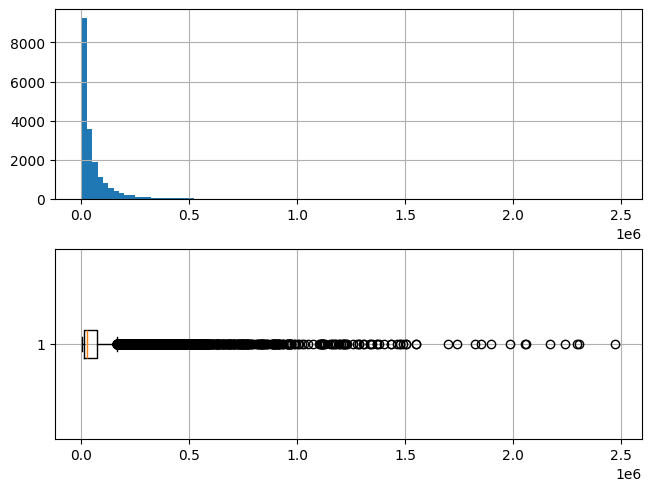

In [7]:
fig, axes = plt.subplots(2,1, layout='constrained')
bed_mrna_len = (bed_mrna[2] - bed_mrna[1])
bed_mrna_len.hist(bins=100, ax=axes[0])
# pd.DataFrame(bed_mrna[2] - bed_mrna[1]).boxplot(ax=axes[1], orientation='horizontal')
plt.boxplot(bed_mrna[2] - bed_mrna[1], vert=False)
plt.grid()

Calculate feature length and sort BED:

In [8]:
bed_mrna['length'] = (bed_mrna[2]-bed_mrna[1])
bed_mrna = bed_mrna.sort_values('length', ascending=True).reset_index(drop=True)
bed_mrna_500k = bed_mrna[bed_mrna['length'] < 500000]

In [9]:
bed_mrna['length'].max()

np.int64(2473538)

A large number of very long features will require a significant amount of memory (footprint increases exponentially with max feature length).

Here we're wrapping `getMultipleMatricesSparse()` in a loop that divides the BED file in chunks so that the amount of bp to process does not exceed `array_size_yield` as an additional safeguard.

Notice the output is not saved but immediately converted to a metaprofile table to reduce memory footprint. Normalization is also disabled - we can normalize the result table manually later. Aggregation type in `metaprofile()` is set to sum to speed things up - later we will average the data ourselves.

In [10]:
flank_5 = 200
flank_3 = 0

array_size_yield = 4*10**8
mps = []
chunk_rows = []
max_len_in_chunk = 0

for index, row in bed_mrna[bed_mrna['length'] <=1500000].iterrows():
    current_len = row['length']
    
    # Check if adding the current row would exceed the size yield.
    # The potential size is calculated as (number of rows in chunk + 1) * length of the current row (which is the longest).
    if chunk_rows and (len(chunk_rows) + 1) * current_len > array_size_yield:
        # Process the current chunk if limit is exceeded
        chunk_df = pd.DataFrame(chunk_rows)
        print(f"Processing chunk with {len(chunk_df)} genes. Max length: {max_len_in_chunk}")
        mp = meta.metaprofile(
            meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                chunk_df, 
                flank_5=flank_5, 
                flank_3=flank_3,
                normalize_libsize=False,
                align_3end=False,
                skip_zeroes=True,
                chunk_baselimit=500000,
                verbose=False
            ),
            agg_type='sum',
            normalize_internal=False
        )
        mps.append(mp)  # Append to list of profile df's
        
        # Start a new chunk with the current row.
        chunk_rows = [row.to_dict()]
        max_len_in_chunk = current_len
    else:
        # Add the current row to the ongoing chunk.
        chunk_rows.append(row.to_dict())
        max_len_in_chunk = current_len

# Process the last chunk after the loop finishes.
if chunk_rows:
    chunk_df = pd.DataFrame(chunk_rows)
    print(f"Processing final chunk with {len(chunk_df)} genes. Max length: {max_len_in_chunk}")
    mp = meta.metaprofile(
            meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                chunk_df, 
                flank_5=flank_5, 
                flank_3=flank_3,
                normalize_libsize=False,
                align_3end=False,
                skip_zeroes=True,
                chunk_baselimit=500000,
                verbose=False
            ),
            agg_type='sum',
            normalize_internal=False
        )
    mps.append(mp)

pd.to_pickle(mps, '../analysis/mps_dedup.pkl')

Processing chunk with 11156 genes. Max length: 35848
Processing chunk with 4399 genes. Max length: 90903
Processing chunk with 2200 genes. Max length: 181731
Processing chunk with 1079 genes. Max length: 370315
Processing chunk with 473 genes. Max length: 845634
Processing final chunk with 94 genes. Max length: 1491100


Now let's average and normalize profiles to library size:

In [11]:
# Add all profiles together
mp02 = mps[0].sparse.to_dense()
for mp in mps[1:]:
    mp02 = mp02.add(mp.sparse.to_dense(), fill_value=0.0)
#Then average
mp02 = mp02 / len(bed_mrna[bed_mrna['length'] <=1500000])

In [12]:
mp02 = meta.normalizeToLibrary(mp02, bigwig_plus, bigwig_minus)

Text(0.5, 1.0, 'mRNAs')

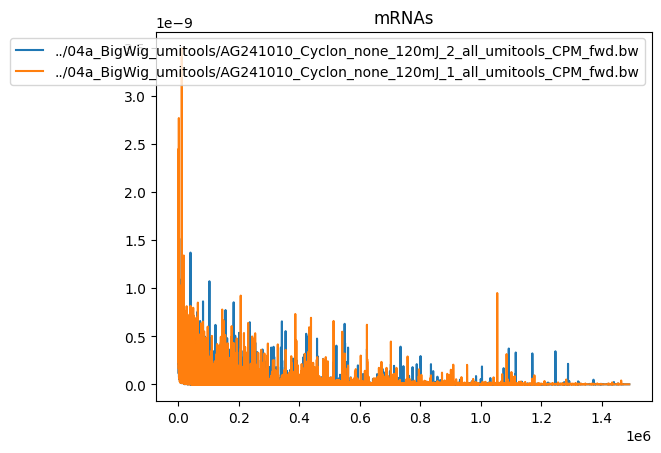

In [13]:
mp02.plot()
plt.title('mRNAs')
# plt.xlim(-50, 2000)
# plt.ylim(0, 0.000000006)

(-200.0, 20000.0)

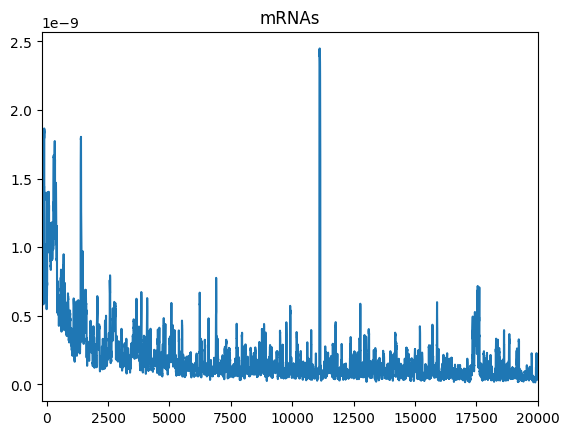

In [14]:
# mp02.mean(1).rolling(1000).mean().plot()
mp02.mean(1).plot()
plt.title('mRNAs')
plt.xlim(-200, 20000)

There seems to be some sort of peak at the 5' end. Let's take a look at 5'- and 3'ends of genes now.

We can use `len_cutoff` to look only at n first bp of genes. Note that we cannot provide a 3' flank in that case.

Notice that we no longer need to use a memory-saving loop as our features are now only 4 kbp long!

In [15]:
# 5'end:
mp03 = meta.metaprofile(
    meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                bed_mrna, 
                flank_5=2000, 
                normalize_libsize=False,
                align_3end=False,
                len_cutoff = 2000,
                skip_zeroes=False,
                chunk_baselimit=500000,
                verbose=False
    ),
    agg_type='mean',
    normalize_internal=False
)

mp03_n = meta.normalizeToLibrary(mp03, bigwig_plus, bigwig_minus)

In [16]:
# 3'end:
mp04 = meta.metaprofile(
    meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                bed_mrna, 
                flank_3=2000, 
                normalize_libsize=False,
                align_3end=True,
                len_cutoff = 2000,
                skip_zeroes=False,
                chunk_baselimit=500000,
                verbose=False
    ),
    agg_type='mean',
    normalize_internal=False
)

mp04_n = meta.normalizeToLibrary(mp04, bigwig_plus, bigwig_minus)

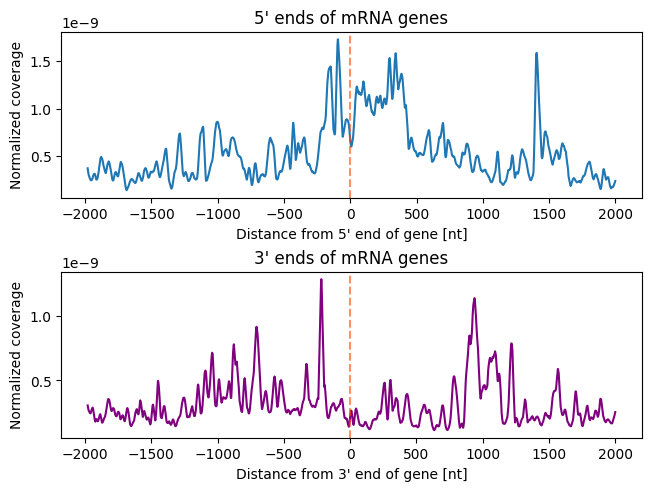

In [18]:
#plotting: 
fig, axes = plt.subplots(2,1, layout='constrained')
mp03_n.mean(1).rolling(20).mean().plot(ax=axes[0])
mp04_n.mean(1).rolling(20).mean().plot(ax=axes[1], c='purple')
for ax in axes:
    ax.axvline(0, linestyle='--', alpha=0.6, c='orangered')
    ax.set_ylabel('Normalized coverage')
axes[0].set_title("5' ends of mRNA genes")
axes[0].set_xlabel("Distance from 5' end of gene [nt]")
axes[1].set_title("3' ends of mRNA genes")
axes[1].set_xlabel("Distance from 3' end of gene [nt]")
plt.savefig('../analysis/01_mRNA.png', dpi=300, bbox_inches='tight')

### snoRNAs

/tmp/ipykernel_15247/426178571.py:14: DeprecationWarning: cleanNames() is deprecated. Please use utils.names.cleanNames() instead.
  mp01 = ttm.cleanNames(mp01, ['../04a_BigWig_umitools/AG241010_', '_none_120mJ_', '_all_dedup_CPM_plus.bw'])


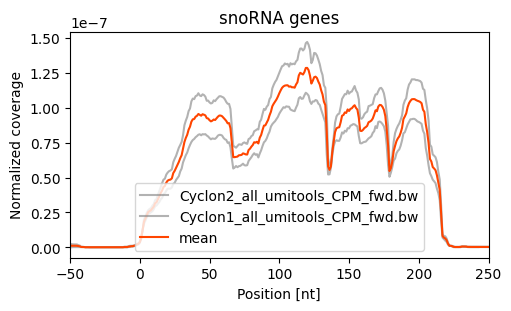

In [22]:
mm01 = meta.getMultipleMatrices(
    bigwig_plus, # list of BigWig files for plus strand
    bigwig_minus, # same for minus strand
    bed[bed['gene_type'] == 'snoRNA'].drop(columns='gene_type'), # BED with features of interes
    flank_5=50, # We can include flanks around our genes
    flank_3=50
)
mp01 = meta.metaprofile(
    mm01,
    agg_type='mean', # for each position, calculate mean across all genes
    normalize_internal=False # whether to normalize each position to the sum of all positions
)

mp01 = ttm.cleanNames(mp01, ['../04a_BigWig_umitools/AG241010_', '_none_120mJ_', '_all_dedup_CPM_plus.bw'])
mp01['mean'] = mp01.mean(axis=1)
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
#plot each library
for col in mp01.columns[:-1]:
    sns.lineplot(data=mp01, x=mp01.index, y=col, label=col, ax=ax, c='grey', alpha=0.6)
# plot mean
sns.lineplot(data=mp01, x=mp01.index, y=mp01.columns[-1], label=mp01.columns[-1], ax=ax, c='orangered')
# sns.lineplot(data=mp01.iloc[:,-1].rolling(window=10, win_type='blackman').mean(), ax=ax, c='orangered')
plt.ylabel('Normalized coverage')
plt.xlabel('Position [nt]')
plt.title("snoRNA genes")
# plt.ylim(0,0.0000012)
plt.xlim(-50, 250)
# plt.legend().set_visible(False)
plt.savefig('../analysis/01_snoRNA.png', dpi=300, bbox_inches='tight')

### lncRNAs

In [23]:
bed_lncrna = bed[bed['gene_type'] == 'lncRNA']
bed_lncrna['length'] = (bed_lncrna[2]-bed_lncrna[1])
bed_lncrna = bed_lncrna.sort_values('length', ascending=True)

/tmp/ipykernel_15247/1759393851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bed_lncrna['length'] = (bed_lncrna[2]-bed_lncrna[1])


In [ ]:
flank_5 = 100
flank_3 = 50

array_size_yield = 5*10**8
mps = []
chunk_rows = []
max_len_in_chunk = 0

for index, row in bed_lncrna.iterrows():
    current_len = row['length']
    
    # Check if adding the current row would exceed the size yield.
    # The potential size is calculated as (number of rows in chunk + 1) * length of the current row (which is the longest).
    if chunk_rows and (len(chunk_rows) + 1) * current_len > array_size_yield:
        # Process the current chunk if limit is exceeded
        chunk_df = pd.DataFrame(chunk_rows)
        print(f"Processing chunk with {len(chunk_df)} genes. Max length: {max_len_in_chunk}")
        mp = meta.metaprofile(
            meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                chunk_df, 
                flank_5=flank_5, 
                flank_3=flank_3,
                normalize_libsize=False,
                align_3end=False,
                skip_zeroes=True,
                chunk_baselimit=500000,
                verbose=False
            ),
            agg_type='sum',
            normalize_internal=False
        )
        mps.append(mp)  # Append to list of profile df's
        
        # Start a new chunk with the current row.
        chunk_rows = [row.to_dict()]
        max_len_in_chunk = current_len
    else:
        # Add the current row to the ongoing chunk.
        chunk_rows.append(row.to_dict())
        max_len_in_chunk = current_len

# Process the last chunk after the loop finishes.
if chunk_rows:
    chunk_df = pd.DataFrame(chunk_rows)
    print(f"Processing final chunk with {len(chunk_df)} genes. Max length: {max_len_in_chunk}")
    mp = meta.metaprofile(
            meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                chunk_df, 
                flank_5=flank_5, 
                flank_3=flank_3,
                normalize_libsize=False,
                align_3end=False,
                skip_zeroes=True,
                chunk_baselimit=500000,
                verbose=False
            ),
            agg_type='sum',
            normalize_internal=False
        )
    mps.append(mp)

pd.to_pickle(mps, '../analysis/mps_lncRNA_dedup.pkl')

Processing chunk with 14491 genes. Max length: 34492
Processing chunk with 2828 genes. Max length: 176732
Processing chunk with 683 genes. Max length: 725484
Processing final chunk with 39 genes. Max length: 1375316


In [25]:
# Add all profiles together
mp05 = mps[0].sparse.to_dense()
for mp in mps[1:]:
    mp05 = mp05.add(mp.sparse.to_dense(), fill_value=0.0)
#Then average
mp05 = mp05 / len(bed_lncrna)

In [26]:
mp05 = meta.normalizeToLibrary(mp05, bigwig_plus, bigwig_minus)

Text(0.5, 1.0, 'lncRNAs')

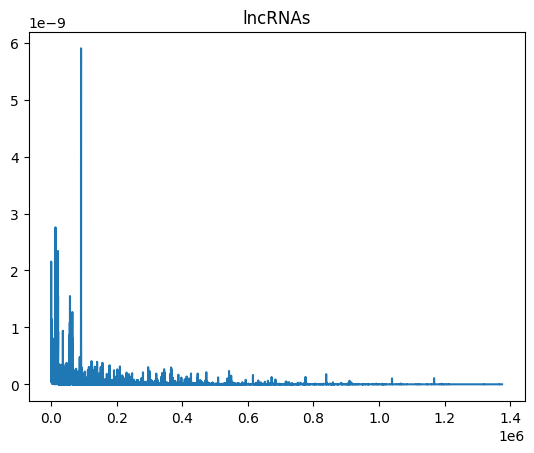

In [27]:
mp05.mean(axis=1).plot()
plt.title('lncRNAs')
# plt.xlim(-100, 2000)
# plt.ylim(0, 0.000000006)

Again there seems to be some binding at 5' ends.

In [28]:
# 5'end:
mp06 = meta.metaprofile(
    meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                bed_lncrna, 
                flank_5=2000, 
                normalize_libsize=False,
                align_3end=False,
                len_cutoff = 2000,
                skip_zeroes=False,
                chunk_baselimit=500000,
                verbose=False
    ),
    agg_type='mean',
    normalize_internal=False
)

mp06_n = meta.normalizeToLibrary(mp06, bigwig_plus, bigwig_minus)

In [29]:
# 3'end:
mp07 = meta.metaprofile(
    meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                bed_lncrna, 
                flank_3=2000, 
                normalize_libsize=False,
                align_3end=True,
                len_cutoff = 2000,
                skip_zeroes=False,
                chunk_baselimit=500000,
                verbose=False
    ),
    agg_type='mean',
    normalize_internal=False
)

mp07_n = meta.normalizeToLibrary(mp07, bigwig_plus, bigwig_minus)

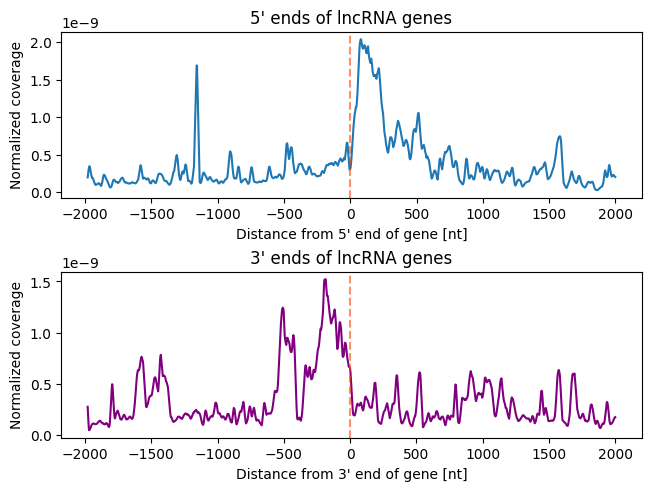

In [31]:
#plotting: 
fig, axes = plt.subplots(2,1, layout='constrained')
mp06_n.mean(1).rolling(20).mean().plot(ax=axes[0])
mp07_n.mean(1).rolling(20).mean().plot(ax=axes[1], c='purple')
for ax in axes:
    ax.axvline(0, linestyle='--', alpha=0.6, c='orangered')
    ax.set_ylabel('Normalized coverage')
axes[0].set_title("5' ends of lncRNA genes")
axes[0].set_xlabel("Distance from 5' end of gene [nt]")
axes[1].set_title("3' ends of lncRNA genes")
axes[1].set_xlabel("Distance from 3' end of gene [nt]")
plt.savefig('../analysis/01_lncRNA.png', dpi=300, bbox_inches='tight')

### snRNAs

In [32]:
bed_snrna = bed[bed['gene_type'] == 'snRNA']

mp08 = meta.metaprofile(
    meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                bed_snrna,
                flank_5=500,
                flank_3=500, 
                normalize_libsize=False,
                align_3end=False,
                skip_zeroes=False,
                chunk_baselimit=500000,
                verbose=False
    ),
    agg_type='mean',
    normalize_internal=False
)

mp08_n = meta.normalizeToLibrary(mp07, bigwig_plus, bigwig_minus)


Text(0.5, 1.0, 'snRNAs')

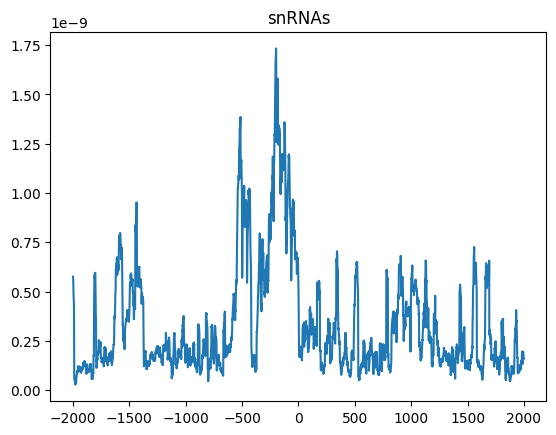

In [33]:
mp08_n.mean(axis=1).plot()
plt.title('snRNAs')

In [34]:
# 5'end:
mp09 = meta.metaprofile(
    meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                bed_snrna, 
                flank_5=2000, 
                flank_3=2000,
                normalize_libsize=False,
                align_3end=False,
                # len_cutoff = 2000,
                skip_zeroes=False,
                chunk_baselimit=500000,
                verbose=False
    ),
    agg_type='mean',
    normalize_internal=False
)

mp09_n = meta.normalizeToLibrary(mp09, bigwig_plus, bigwig_minus)

In [35]:
# 3'end:
mp10 = meta.metaprofile(
    meta.getMultipleMatricesSparse(
                bigwig_plus, 
                bigwig_minus, 
                bed_snrna, 
                flank_5=2000,
                flank_3=2000, 
                normalize_libsize=False,
                align_3end=True,
                # len_cutoff = 2000,
                skip_zeroes=False,
                chunk_baselimit=500000,
                verbose=False
    ),
    agg_type='mean',
    normalize_internal=False
)

mp10_n = meta.normalizeToLibrary(mp10, bigwig_plus, bigwig_minus)

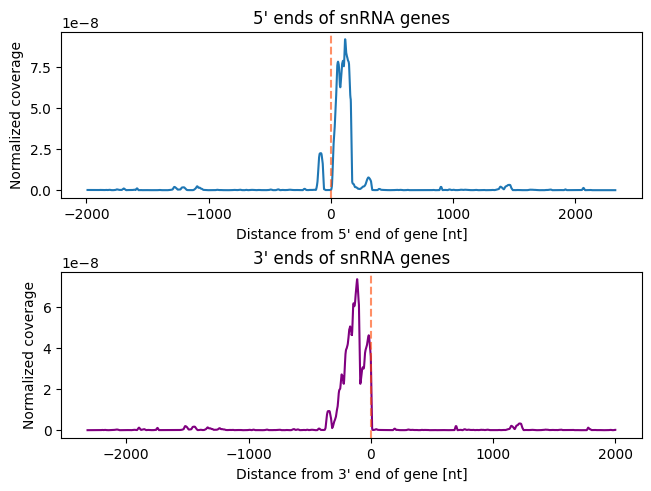

In [37]:
#plotting: 
fig, axes = plt.subplots(2,1, layout='constrained')
mp09_n.mean(1).rolling(10).mean().plot(ax=axes[0])
mp10_n.mean(1).rolling(10).mean().plot(ax=axes[1], c='purple')
for ax in axes:
    ax.axvline(0, linestyle='--', alpha=0.6, c='orangered')
    ax.set_ylabel('Normalized coverage')
axes[0].set_title("5' ends of snRNA genes")
axes[0].set_xlabel("Distance from 5' end of gene [nt]")
axes[1].set_title("3' ends of snRNA genes")
axes[1].set_xlabel("Distance from 3' end of gene [nt]")
plt.savefig('../analysis/01_snRNA.png', dpi=300, bbox_inches='tight')